In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv('../datasets/house-train.csv',usecols=['GarageArea','LotArea','SalePrice'])

In [40]:
df.head()

,LotArea,GarageArea,SalePrice
0,8450,548,208500
1,9600,460,181500
2,11250,608,223500
3,9550,642,140000
4,14260,836,250000


In [41]:
df = df.dropna()

In [42]:
X = df.iloc[:,:2]
y = df.iloc[:,2:]

In [43]:
X

,LotArea,GarageArea
0,8450,548
1,9600,460
2,11250,608
3,9550,642
4,14260,836
...,...,...
1455,7917,460
1456,13175,500
1457,9042,252
1458,9717,240


In [44]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred = lr.predict(X_test)

# 1. Linear Relationship

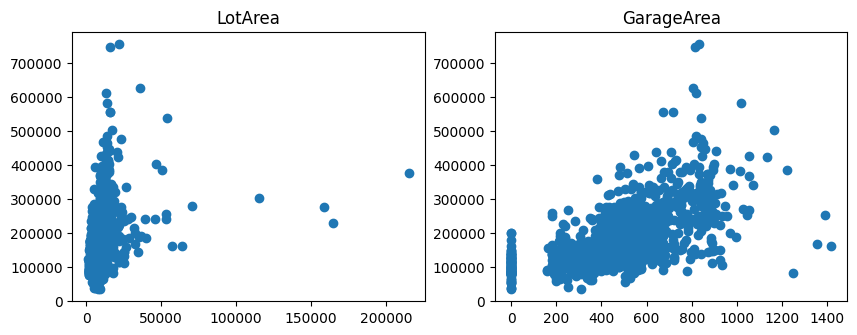

In [55]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize = (10, 3.5))
ax1.scatter(df['LotArea'],df['SalePrice'])
ax1.set_title("LotArea")
ax2.scatter(df['GarageArea'],df['SalePrice'])
ax2.set_title("GarageArea")
plt.show()
#The right plot shows garage size has an linear relation with target col, left one shows LotArea does not have

# 2. Multicollinearity

<Axes: >

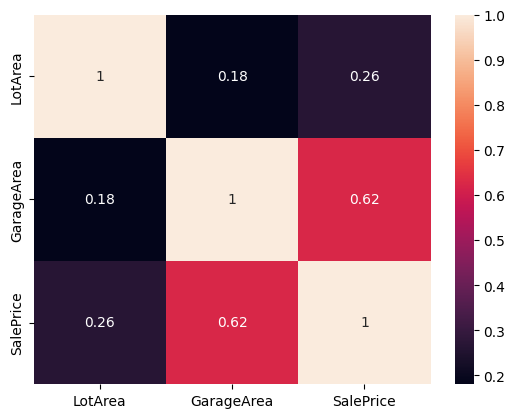

In [59]:
sns.heatmap(df.iloc[:,:3].corr(),annot=True)
#We check multicollinearity between features (NOT target at all), They should be as less correlation as possible i.e. as closer to 0 as possible.
#Here between GarageArea and LotArea it is 0.18 which is very weak

# 3. Normality of Residual

In [60]:
residual = y_test - y_pred

<Axes: ylabel='Count'>

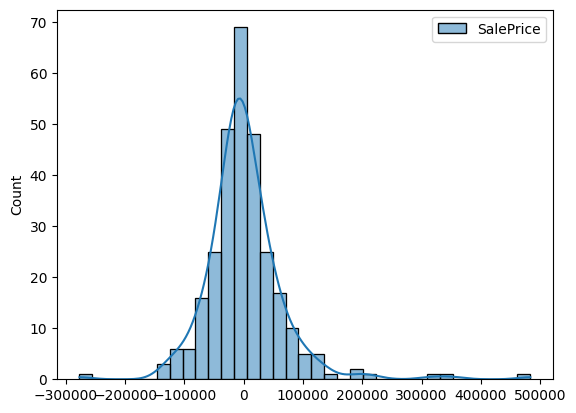

In [62]:
sns.histplot(residual, kde=True)

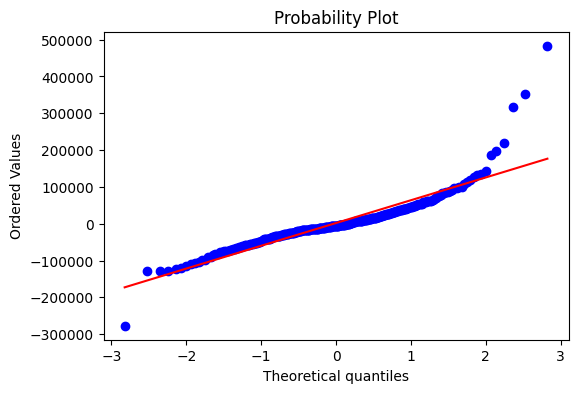

In [70]:
import scipy as sp
fig,ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual.squeeze(),plot=ax,fit=True)
plt.show()

In [ ]:
#From both the graphs we can see that the residual is approximately normal but a little right skewed

# 4. Homoscedasticity

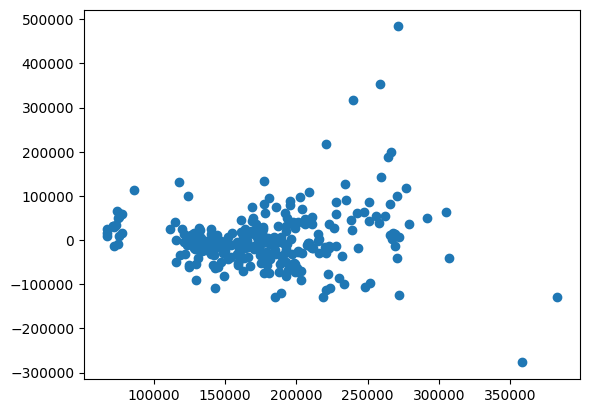

In [72]:
plt.scatter(y_pred,residual)

In [73]:
# At 0 the residuals are randomly distributed, no curved relationship i.e. maintaining randomness, at higher values the spread is increasing and not randoam at 0.
# Therefore it is partially satisfied

# 5. Autocorrelation of Residuals

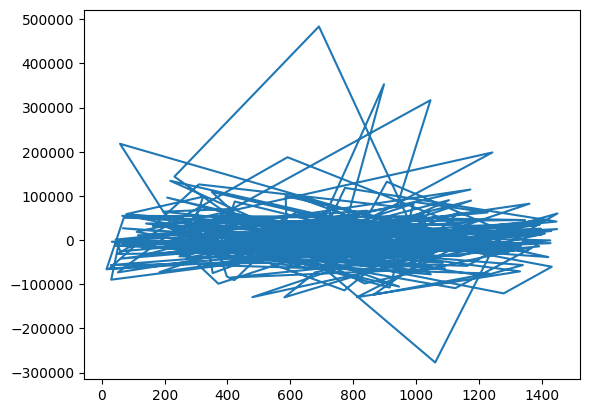

In [74]:
plt.plot(residual)

In [75]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual.squeeze())
print(dw)

1.835050654632833


In [76]:
#The graph is messed up, the durbin watson statistic gives 1.83 which is close to 2(No autocorrelation) therefore it has no significat autocorrelation